<h1>Application of Closed-loop learning to k-means clustering of Iris dataset</h1>

<h2>Gabriele Cerioli, Bsc Physics, University of Trieste</h2>

<h3>Defining Euclidean distance and the main function kmeans</h3>

In [1]:
def euclidean_distance(a, b):
    # Euclidean distance between two vectors
    return np.linalg.norm(a - b)
from sklearn.cluster import KMeans
import numpy as np

In [2]:
def mean_clusters(data_matrix, cluster_assignments, n_clusters):
    import numpy as np
    cluster_assignments = cluster_assignments.astype(int)  # ensure integer indices
    
    # Sum of points per cluster
    sums = np.zeros((n_clusters, data_matrix.shape[1]))
    np.add.at(sums, cluster_assignments, data_matrix)
    
    # Count of points per cluster
    counts = np.bincount(cluster_assignments, minlength=n_clusters).reshape(-1, 1)
    
    # Mean = sums / counts (safe division)
    mean_cluster = np.divide(sums, counts, where=counts > 0)
    return mean_cluster


def variance_clusters(data_matrix, cluster_assignments, n_clusters):
    import numpy as np
    # Compute cluster means first
    mean_cluster = mean_clusters(data_matrix, cluster_assignments, n_clusters)
    
    # Sum of squared deviations per cluster
    sq_dev = np.zeros((n_clusters, data_matrix.shape[1]))
    np.add.at(sq_dev, cluster_assignments, (data_matrix - mean_cluster[cluster_assignments])**2)
    
    # Count of points per cluster
    counts = np.bincount(cluster_assignments, minlength=n_clusters).reshape(-1, 1)
    
    # Variance = sum of squared deviations / count
    variance_cluster = np.divide(sq_dev, counts, where=counts>0)
    return variance_cluster

In [3]:


def plot_clusters(data_matrix, cluster_assignments, centroids):
    import matplotlib.pyplot as plt
    
    # Define feature pairs to plot (x_index, y_index, x_label, y_label)
    feature_pairs = [
        (0, 1, "Sepal Length (cm)", "Sepal Width (cm)"),
        (0, 2, "Sepal Length (cm)", "Petal Length (cm)"),
        (0, 3, "Sepal Length (cm)", "Petal Width (cm)"),
        (1, 2, "Sepal Width (cm)", "Petal Length (cm)"),
        (1, 3, "Sepal Width (cm)", "Petal Width (cm)"),
        (2, 3, "Petal Length (cm)", "Petal Width (cm)")
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(10, 8))  # 2 rows, 3 columns
    axes = axes.ravel()  # flatten 2D array of axes
    
    for ax, (x_idx, y_idx, x_label, y_label) in zip(axes, feature_pairs):
        # Scatter plot of points colored by cluster
        ax.scatter(data_matrix[:, x_idx], data_matrix[:, y_idx],
                   c=cluster_assignments, cmap='winter', alpha=0.6)
        # Scatter plot of centroids
        ax.scatter(centroids[:, x_idx], centroids[:, y_idx],
                   c='red', marker='X', s=100, label='Centroids')
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
    
    # Add legend only to the first subplot
    axes[0].legend()
    
    fig.suptitle("Visualisation of Clusters and their Centroids", fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return



In [6]:
def update_dataset(data_matrix, cluster_assignments, M, n_clusters, random_state=None):
    import numpy as np
    means=mean_clusters(data_matrix,cluster_assignments,n_clusters)
    variances=variance_clusters(data_matrix,cluster_assignments,n_clusters)

    rng = np.random.default_rng(random_state)

    cluster_assignments = cluster_assignments.astype(int)
    
    # Calcola la distribuzione dei cluster (peso proporzionale alla dimensione del cluster)
    weights = np.bincount(cluster_assignments, minlength=means.shape[0]).astype(float)
    weights /= weights.sum()
    
    # Se variances ha zeri, aggiungo un rumore minimo per evitare errori
    safe_variances = np.where(variances == 0, 1e-6, variances)

    # Scelta dei cluster per generare punti sintetici
    cluster_indices = rng.choice(len(means), size=M, p=weights)
    
    # Generazione dei punti sintetici dalla distribuzione dei cluster
    synthetic_points = rng.normal(loc=means[cluster_indices], scale=np.sqrt(safe_variances[cluster_indices]))

    # 🔥 Aggiungo i nuovi punti al dataset originale
    new_data = np.vstack((data_matrix, synthetic_points))

    return new_data



<h3>Main Algorithm</h3>

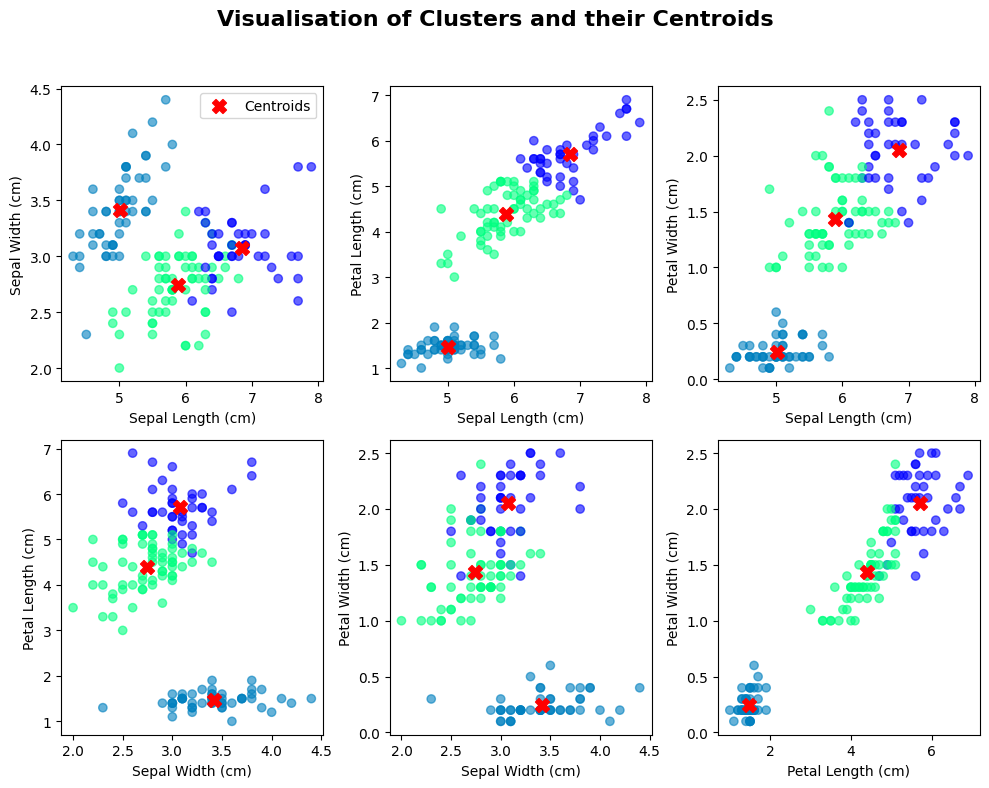

39 50 61
Original Means: [[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.418      1.464      0.244     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]
Original variances: [[0.2322288  0.08023669 0.25360947 0.08556213]
 [0.121764   0.142276   0.029504   0.011264  ]
 [0.19743617 0.08438592 0.2574093  0.08848697]]
Means: [[5.0512824  3.43074179 1.47213473 0.25842982]
 [5.90901756 2.76821525 4.44257064 1.4880312 ]
 [6.88229127 3.06446098 5.83962422 2.07186652]]
Variances: [[0.10213935 0.14551465 0.02939351 0.00702002]
 [0.18901118 0.06965536 0.20006533 0.0713504 ]
 [0.22743574 0.06478349 0.21428992 0.07049596]]


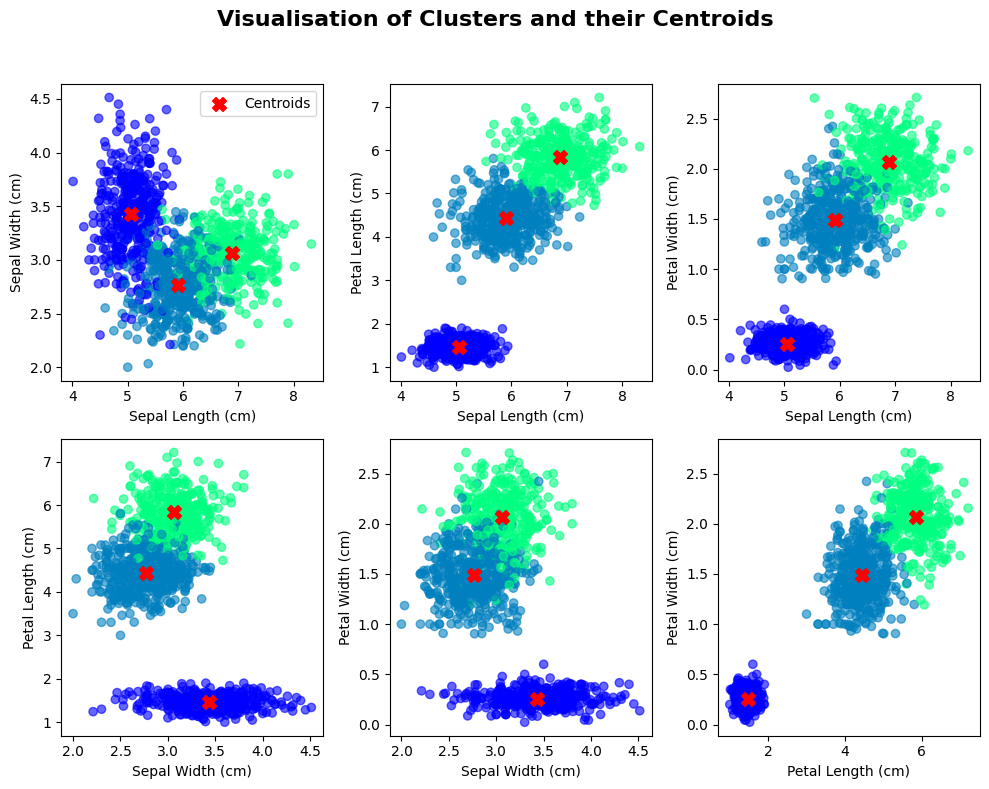

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

M = 10  # points to be added as synthetic data
df = pd.read_csv('Iris.csv')

selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
data_matrix = df[selected_columns].to_numpy()

# Initial fit of KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(data_matrix)
cluster_assignments = kmeans.labels_

# Compute cluster means using the existing helper
centers = mean_clusters(data_matrix, cluster_assignments, 3)

plot_clusters(data_matrix, cluster_assignments, centers)

print(np.sum(cluster_assignments == 0),
      np.sum(cluster_assignments == 1),
      np.sum(cluster_assignments == 2))

new_data = data_matrix.copy()
steps = 100  # Number of iterations
means = mean_clusters(data_matrix, cluster_assignments, 3)
variances = variance_clusters(data_matrix, cluster_assignments, 3)

print("Original Means:", means)
print("Original variances:", variances)

# Iteratively augment the dataset and re-cluster.
for i in range(steps):
    # Re-fit KMeans on the current dataset and obtain assignments
    kmeans = KMeans(n_clusters=3, random_state=42)
    cluster_assignments = kmeans.fit_predict(new_data)
    
    # Recompute cluster statistics on the updated dataset
    means = mean_clusters(new_data, cluster_assignments, 3)
    variances = variance_clusters(new_data, cluster_assignments, 3)
    
    # Update dataset by adding synthetic points sampled from cluster distributions
    # Pass n_clusters as integer (3) to match update_dataset signature.
    new_data = update_dataset(new_data, cluster_assignments, M, 3, random_state=42 + i)

# Final recomputation on the resulting dataset
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_assignments = kmeans.fit_predict(new_data)
means = mean_clusters(new_data, cluster_assignments, 3)
variances = variance_clusters(new_data, cluster_assignments, 3)

print("Means:", means)
print("Variances:", variances)
plot_clusters(new_data, cluster_assignments, means)


In [17]:
from scipy.stats import multivariate_normal
def assign_clusters_gaussian(X, means, variances):
    
    K = means.shape[0]
    N = data_matrix.shape[0]

    # Se variances è diagonale → costruiamo matrici di covarianza
    covs = np.array([np.diag(var) for var in variances])

    # Calcolo delle probabilità gaussiane
    log_probs = np.zeros((N, K))
    for k in range(K):
        rv = multivariate_normal(mean=means[k], cov=covs[k], allow_singular=True)
        log_probs[:, k] = rv.logpdf(X)

    # Assegnazione al cluster con max log-probability
    cluster_assignments = np.argmax(log_probs, axis=1)
    return cluster_assignments

print(assign_clusters_gaussian(data_matrix,means,variances))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 2
 2 2 1 2 2 2 2 2 1 2 1 2 1 2 2 1 1 2 2 2 2 2 1 1 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]
